In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, brier_score_loss, confusion_matrix, mean_squared_error, r2_score
from dataretrieval import nwis
import optuna
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

%config InlineBackend.figure_format = "retina"

Geopandas not installed. Geometries will be flattened into pandas DataFrames.


/home/u5/tiffanyle/venvs/sprnca/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
dir = os.path.join("..", "Data")
seed = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

start, end = "2006-01-01", "2025-12-31"
history_start = "2005-01-01" 
cameras = {"Fairbank": 1, "CharlestonMesquite": 2, "Moson": 3, "Hunter": 4, "Hereford": 5, "Contention": 6, "St.David": 7, "Boquillas": 8}
gages = {
    "09470500": (31.380131, -110.111209), # Palominas
    "09470920": (31.554444, -110.140000), # Lewis Springs
    "09471000": (31.625942, -110.175103), # Charleston
    "09471550": (31.751444, -110.201333), # near Tombstone
}

continuous = ["prcp", "tmax", "tmin", "vpd", "et", "gw", "q"]
log_features = ["prcp", "q"] # heavily right-skewed with many zeros
site_features = [f"cam_{c}" for c in cameras.values()]
features = continuous + site_features

test_frac = 0.2 # Fraction of water years held out for testing
val_frac = 0.2  # Fraction of remaining water years for tuning

torch.manual_seed(seed)
np.random.seed(seed)

## Load data

In [ ]:
def load_fp():
    flow = pd.read_csv(os.path.join(dir, "USPPFlowMonitoring2006_2025.csv"), parse_dates = ["Date"])
    flow = flow[flow["Site"].isin(cameras)]
    flow["fp"] = np.select([flow["Flow Code"].eq(0), flow["Flow Code"].isin([1, 2])], [0, 1], default = np.nan)
    return flow.rename(columns = {"Site": "site", "Date": "date"}).groupby(["site", "date"])["fp"].max()

def load_climate():
    climate = pd.concat([pd.read_csv(os.path.join(dir, f)) for f in ["Daymet2005.csv", "Daymet2006_2025.csv"]])
    climate["date"] = pd.to_datetime(climate["date"], format = "mixed")
    climate = climate.rename(columns = {"tvpd": "vpd"})
    return climate.set_index(["site", "date"])[["prcp", "tmax", "tmin", "vpd"]]

def load_et():
    raw = pd.read_csv(os.path.join(dir, "ET", "NaglerET.csv"), header = None, skiprows = 7)
    columns = {"Hereford": (3, 6), "Hunter": (3, 12), "Moson": (3, 18), "CharlestonMesquite": (3, 24),
               "Boquillas": (3, 30), "Fairbank": (3, 36), "Contention": (54, 57), "St.David": (54, 63)}
    et = []
    for site, (date_col, avg_col) in columns.items():
        s = raw[[date_col, avg_col]].dropna()
        s.columns = ["date", "et"]
        s["date"] = pd.to_datetime(s["date"], format = "mixed") + pd.Timedelta(days = 8)
        s["et"] = pd.to_numeric(s["et"], errors = "coerce")
        s["site"] = site
        et.append(s)
    return pd.concat(et).set_index(["site", "date"])["et"]

def load_gw():
    gw = pd.read_csv(os.path.join(dir, "GW", "CamSPRNCA_GW.csv"))
    gw["date"] = pd.to_datetime(gw["datetime"], format = "mixed")
    gw["gw"] = gw["height_abv_lowest_ft"] * 0.3048
    return gw.groupby(["site", "date"])["gw"].mean()

def load_q():
    """Daily mean discharge (cfs) from the nearest USGS gage (with data) to each camera."""
    cache = os.path.join(dir, "SPRNCA_Q.csv")
    if not os.path.exists(cache):
        q, _ = nwis.get_dv(sites = list(gages), start = history_start, end = end, parameterCd = "00060", statCd = "00003")
        q = q.reset_index()
        q["date"] = pd.to_datetime(q["datetime"]).dt.tz_localize(None)
        q[["site_no", "date", "00060_Mean"]].to_csv(cache, index = False)
    q = pd.read_csv(cache, dtype = {"site_no": str}, parse_dates = ["date"]).set_index(["site_no", "date"])["00060_Mean"]
    with_data = list(q.index.unique("site_no"))

    lat, lon = np.array([gages[g] for g in with_data]).T
    flow = pd.read_csv(os.path.join(dir, "USPPFlowMonitoring2006_2025.csv"))
    locs = flow[flow["Site"].isin(cameras)].groupby("Site")[["Latitude", "Longitude"]].first()
    dlat = locs["Latitude"].values[:, None] - lat
    dlon = (locs["Longitude"].values[:, None] - lon) * np.cos(np.radians(31.6))
    nearest = dict(zip(locs.index, np.array(with_data)[np.hypot(dlat, dlon).argmin(axis = 1)]))

    return pd.concat({site: q.loc[gage] for site, gage in nearest.items()}, names = ["site", "date"]).rename("q")

In [4]:
days = pd.date_range(history_start, end, freq = "D")
index = pd.MultiIndex.from_product([list(cameras), days], names = ["site", "date"])

sources = [load_climate(), load_et(), load_gw(), load_q()]
frames = []
for site in cameras:
    site_df = pd.concat([s.loc[site] for s in sources], axis = 1).sort_index()
    site_df = site_df.interpolate(method = "time", limit_direction = "both").reindex(days)
    site_df["site"] = site
    frames.append(site_df)

df = pd.concat(frames).rename_axis("date").reset_index()
df = df.merge(load_fp().reset_index(), on = ["site", "date"], how = "left")
df["wy"] = df["date"].dt.year + (df["date"].dt.month >= 10)
for site, cam in cameras.items():
    df[f"cam_{cam}"] = (df["site"] == site).astype(float)

df[continuous + ["fp"]].describe().round(2)

,prcp,tmax,tmin,vpd,et,gw,q,fp
count,58440.00,58440.00,58440.00,58440.00,58440.00,58440.00,58440.00,45605.00
mean,0.86,27.19,9.18,1.79,2.54,4.54,27.56,0.83
std,3.19,7.54,7.57,0.89,1.64,2.94,195.69,0.38
min,0.00,-1.40,-14.34,0.15,0.21,0.63,0.00,0.00
25%,0.00,21.41,2.88,1.13,0.96,2.08,0.00,1.00
50%,0.00,28.06,8.81,1.58,2.22,3.39,2.94,1.00
75%,0.00,33.34,16.37,2.37,4.06,6.93,9.76,1.00
max,59.48,44.11,24.95,4.88,6.42,10.48,10900.00,1.00


## Train / Validation / Test Split

In [5]:
rng = np.random.default_rng(seed)
years = np.array(sorted(df.loc[df["fp"].notna(), "wy"].unique()))
test_years = rng.choice(years, size = round(len(years) * test_frac), replace = False)
remaining = np.setdiff1d(years, test_years)
val_years = rng.choice(remaining, size = round(len(remaining) * val_frac), replace = False)
train_years = np.setdiff1d(remaining, val_years)

df["split"] = np.select([df["date"] < start, df["wy"].isin(test_years), df["wy"].isin(val_years)], ["history", "test", "val"], default = "train")
print("Train WY:", train_years)
print("Val WY:  ", np.sort(val_years))
print("Test WY: ", np.sort(test_years))

scaled = df.copy()
scaled[log_features] = np.log1p(scaled[log_features].clip(lower = 0))
scaler = StandardScaler().fit(scaled.loc[scaled["split"] == "train", continuous])
scaled[continuous] = scaler.transform(scaled[continuous])

def make_sequences(seq_len):
    """Windows of the seq_len days ending on (and including) each labelled day."""
    x, y, meta = [], [], []
    for site in cameras:
        s = scaled[scaled["site"] == site].sort_values("date")
        values = s[features].to_numpy(dtype = np.float32)
        windows = np.lib.stride_tricks.sliding_window_view(values, seq_len, axis = 0).transpose(0, 2, 1)
        ends = s.iloc[seq_len - 1:]
        keep = ends["fp"].notna().to_numpy()
        x.append(windows[keep])
        y.append(ends.loc[keep, "fp"].to_numpy(dtype = np.float32))
        meta.append(ends.loc[keep, ["site", "date", "wy", "split"]])
    meta = pd.concat(meta, ignore_index = True)
    return np.concatenate(x), np.concatenate(y), meta

def loader(x, y, batch_size, shuffle = False):
    return DataLoader(TensorDataset(torch.from_numpy(x), torch.from_numpy(y)), batch_size = batch_size, shuffle = shuffle)

Train WY: [2006 2007 2008 2009 2012 2013 2014 2015 2016 2019 2021 2023 2024]
Val WY:   [2017 2020 2022]
Test WY:  [2010 2011 2018 2025]


## Model

In [6]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first = True, bidirectional = True,
                            dropout = dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :])).squeeze(-1)

def predict(model, data):
    model.eval()
    with torch.no_grad():
        return np.concatenate([torch.sigmoid(model(xb.to(device))).cpu().numpy() for xb, _ in data])

def train(model, train_data, val_data, lr, epochs, patience, trial = None):
    """Early-stops on val_data and returns (model, best val loss, best epoch); with val_data = None, trains for exactly `epochs`."""
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    loss_fn = nn.BCEWithLogitsLoss()
    best_loss, best_state, best_epoch, wait = np.inf, None, epochs, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_data:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss_fn(model(xb), yb).backward()
            optimizer.step()
        if val_data is None:
            continue

        model.eval()
        with torch.no_grad():
            val_loss = np.mean([loss_fn(model(xb.to(device)), yb.to(device)).item() for xb, yb in val_data])
        if trial is not None:
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if val_loss < best_loss:
            best_loss, best_state, best_epoch, wait = val_loss, {k: v.detach().clone() for k, v in model.state_dict().items()}, epoch + 1, 0
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_loss, best_epoch

## Tune hyperparameters

In [ ]:
max_trials = 2000
stall = 200
max_expansions = 20

space = {
    "seq_len": {"low": 14, "high": 365, "step": 7, "floor": 7, "ceil": 365},
    "hidden_size": {"low": 16, "high": 256, "step": 8, "floor": 8, "ceil": 512},
    "num_layers": {"low": 1, "high": 4, "step": 1, "floor": 1, "ceil": 6},
    "dropout": {"low": 0.0, "high": 0.6, "step": 0.05, "floor": 0.0, "ceil": 0.9},
    "lr": {"low": 1e-5, "high": 3e-2, "log": True, "floor": 1e-6, "ceil": 1e-1},
    "log2_batch": {"low": 4, "high": 8, "step": 1, "floor": 3, "ceil": 10},
}

def suggest(trial, name):
    spec = space[name]
    if spec.get("log"):
        return trial.suggest_float(name, spec["low"], spec["high"], log = True)
    if isinstance(spec["step"], int):
        return trial.suggest_int(name, spec["low"], spec["high"], step = spec["step"])
    return trial.suggest_float(name, spec["low"], spec["high"], step = spec["step"])

def widen_edges(best):
    widened = False
    for name, spec in space.items():
        f = np.log10 if spec.get("log") else (lambda v: v)
        lo, hi, value = f(spec["low"]), f(spec["high"]), f(best[name])
        tol = 0.02 * (hi - lo) if spec.get("log") else spec["step"] / 2
        shift = 0.5 * (hi - lo)
        if value <= lo + tol:
            new = 10 ** (lo - shift) if spec.get("log") else lo - shift
            new = max(new, spec["floor"])
        elif value >= hi - tol:
            new = 10 ** (hi + shift) if spec.get("log") else hi + shift
            new = min(new, spec["ceil"])
        else:
            continue
        if not spec.get("log"):
            new = round(new / spec["step"]) * spec["step"]
        side = "low" if value <= lo + tol else "high"
        if new != spec[side]:
            print(f"Widening {name} {side}: {spec[side]} -> {new}")
            spec[side] = type(spec[side])(new)
            widened = True
    return widened

cache = {}

def objective(trial):
    params = {name: suggest(trial, name) for name in space}
    if params["seq_len"] not in cache:
        if len(cache) >= 4:
            cache.pop(next(iter(cache)))
        cache[params["seq_len"]] = make_sequences(params["seq_len"])
    x, y, meta = cache[params["seq_len"]]
    tr, va = (meta["split"] == "train").to_numpy(), (meta["split"] == "val").to_numpy()

    model, oom = None, False
    try:
        model = BiLSTMClassifier(len(features), params["hidden_size"], params["num_layers"], params["dropout"]).to(device)
        _, val_loss, _ = train(model, loader(x[tr], y[tr], 2 ** params["log2_batch"], shuffle = True), loader(x[va], y[va], 256),
                            params["lr"], epochs = 100, patience = 7, trial = trial)
    except RuntimeError as e:
        if "out of memory" not in str(e):
            raise
        oom = True
    del model
    torch.cuda.empty_cache()
    if oom:
        raise optuna.TrialPruned("CUDA out of memory")
    return val_loss

torch.manual_seed(seed)
study = optuna.create_study(direction = "minimize", sampler = optuna.samplers.TPESampler(seed = seed, n_startup_trials = 50),
                            pruner = optuna.pruners.MedianPruner(n_startup_trials = 4, n_warmup_steps = 5))
round_start = 0
study_path = os.path.join(dir, "SPRNCAStudy.pkl")

def save_study(study, trial):
    with open(study_path + ".tmp", "wb") as f:
        pickle.dump(study, f)
    os.replace(study_path + ".tmp", study_path)

def stop_early(study, trial):
    try:
        last_gain = max(study.best_trial.number, round_start) # a widened round gets a fresh `stall` trials
    except ValueError:
        return
    if len(study.trials) >= max_trials or trial.number - last_gain >= stall:
        study.stop()

for round_num in range(max_expansions + 1):
    round_start = len(study.trials)
    study.optimize(objective, n_trials = max_trials - len(study.trials), callbacks = [save_study, stop_early], gc_after_trial = True, show_progress_bar = True)
    if len(study.trials) >= max_trials or round_num == max_expansions or not widen_edges(study.best_params):
        break
print(f"{len(study.trials)} trials; best was trial {study.best_trial.number}")

best = {**study.best_params, "batch_size": 2 ** study.best_params["log2_batch"], "val_bce": study.best_value}
pd.DataFrame([best]).to_csv(os.path.join(dir, "SPRNCAParams.csv"), index = False)
best


  0%|          | 0/100 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.124788:   0%|          | 0/100 [14:01<?, ?it/s]


Best trial: 0. Best value: 0.124788:   1%|          | 1/100 [14:01<23:08:33, 841.55s/it]


Best trial: 0. Best value: 0.124788:   1%|          | 1/100 [14:26<23:08:33, 841.55s/it]


Best trial: 0. Best value: 0.124788:   2%|▏         | 2/100 [14:26<9:49:59, 361.22s/it] 

...


Best trial: 98. Best value: 0.10666:  99%|█████████▉| 99/100 [2:29:38<00:47, 47.46s/it]


Best trial: 98. Best value: 0.10666:  99%|█████████▉| 99/100 [2:29:51<00:47, 47.46s/it]


Best trial: 98. Best value: 0.10666: 100%|██████████| 100/100 [2:29:51<00:00, 37.02s/it]


Best trial: 98. Best value: 0.10666: 100%|██████████| 100/100 [2:29:51<00:00, 89.91s/it]

{'seq_len': 84,
 'hidden_size': 128,
 'num_layers': 1,
 'dropout': 0.2,
 'lr': 0.00016540611583308696,
 'log2_batch': 6,
 'batch_size': 64,
 'val_bce': 0.10665991605994099}

## Train and Evaluate

In [8]:
params = pd.read_csv(os.path.join(dir, "SPRNCAParams.csv")).iloc[0]
seq_len, hidden_size, num_layers = int(params["seq_len"]), int(params["hidden_size"]), int(params["num_layers"])
dropout, lr, batch_size = float(params["dropout"]), float(params["lr"]), int(params["batch_size"])

x, y, meta = make_sequences(seq_len)
tr, va, te = [(meta["split"] == s).to_numpy() for s in ["train", "val", "test"]]

torch.manual_seed(seed)
model = BiLSTMClassifier(len(features), hidden_size, num_layers, dropout).to(device)
model, _, best_epoch = train(model, loader(x[tr], y[tr], batch_size, shuffle = True), loader(x[va], y[va], 1024), lr, epochs = 100, patience = 15)
torch.save({"state_dict": model.state_dict(), "params": params.to_dict(), "best_epoch": best_epoch}, os.path.join(dir, "SPRNCAModel.pt"))
print(f"Best epoch: {best_epoch}")

meta["fp"] = y
meta["prob"] = predict(model, loader(x, y, 1024))
meta["pred"] = (meta["prob"] >= 0.5).astype(int)

def scores(d):
    return pd.Series({
        "n": len(d),
        "Accuracy": accuracy_score(d["fp"], d["pred"]),
        "Balanced accuracy": balanced_accuracy_score(d["fp"], d["pred"]),
        "F1 (flow)": f1_score(d["fp"], d["pred"], pos_label = 1),
        "F1 (no flow)": f1_score(d["fp"], d["pred"], pos_label = 0),
        "ROC AUC": roc_auc_score(d["fp"], d["prob"]) if d["fp"].nunique() == 2 else np.nan,
        "Brier": brier_score_loss(d["fp"], d["prob"]),
        "RMSE": np.sqrt(mean_squared_error(d["fp"], d["prob"])),
        "R^2": r2_score(d["fp"], d["prob"]),
    })

test = meta[te]
print("Test confusion matrix (rows = observed no flow/flow, cols = predicted):")
print(confusion_matrix(test["fp"], test["pred"]))
display(meta.groupby("split").apply(scores).loc[["train", "val", "test"]].round(3))
display(test.groupby("site").apply(scores).round(3))

Test confusion matrix (rows = observed no flow/flow, cols = predicted):
[[1363  233]
 [ 333 4782]]


,n,Accuracy,Balanced accuracy,F1 (flow),F1 (no flow),ROC AUC,Brier,RMSE,R^2
split,,,,,,,,,
train,31617.0,0.964,0.932,0.978,0.885,0.991,0.027,0.165,0.794
val,7277.0,0.950,0.917,0.969,0.861,0.985,0.036,0.190,0.755
test,6711.0,0.916,0.894,0.944,0.828,0.967,0.063,0.250,0.654


,n,Accuracy,Balanced accuracy,F1 (flow),F1 (no flow),ROC AUC,Brier,RMSE,R^2
site,,,,,,,,,
Boquillas,744.0,1.000,1.000,1.000,0.000,NaN,0.000,0.000,0.000
CharlestonMesquite,809.0,0.969,0.886,0.983,0.783,0.993,0.018,0.133,0.730
Contention,974.0,0.928,0.920,0.896,0.945,0.972,0.055,0.234,0.757
Fairbank,1090.0,0.864,0.829,0.911,0.714,0.928,0.105,0.325,0.390
Hereford,585.0,1.000,1.000,1.000,0.000,NaN,0.000,0.008,0.000
Hunter,898.0,0.889,0.900,0.933,0.660,0.973,0.063,0.251,0.394
Moson,808.0,1.000,1.000,1.000,0.000,NaN,0.000,0.000,0.000
St.David,803.0,0.722,0.686,0.570,0.795,0.738,0.226,0.476,-0.053


## Refit

In [ ]:
torch.manual_seed(seed)
model_all = BiLSTMClassifier(len(features), hidden_size, num_layers, dropout).to(device)
model_all, _, _ = train(model_all, loader(x, y, batch_size, shuffle = True), None, lr, epochs = best_epoch, patience = None)
torch.save({"state_dict": model_all.state_dict(), "params": params.to_dict(), "epochs": best_epoch}, os.path.join(dir, "SPRNCAModelAll.pt"))


## Gap-Fill

In [ ]:
values = scaled.sort_values(["site", "date"])
all_x, all_meta = [], []
for site in cameras:
    s = values[values["site"] == site]
    all_x.append(np.lib.stride_tricks.sliding_window_view(s[features].to_numpy(dtype = np.float32), seq_len, axis = 0).transpose(0, 2, 1))
    all_meta.append(s.iloc[seq_len - 1:][["site", "date"]])
all_x, all_meta = np.concatenate(all_x), pd.concat(all_meta, ignore_index = True)
all_data = loader(all_x, np.zeros(len(all_x), dtype = np.float32), 1024)
all_meta["prob"] = predict(model, all_data)
all_meta["prob_all"] = predict(model_all, all_data)

out = df[["site", "date", "wy", "split"] + continuous + ["fp"]].merge(all_meta, on = ["site", "date"], how = "left")
out = out[out["date"] >= start].reset_index(drop = True)
out["fp_final"] = out["fp"].fillna((out["prob_all"] >= 0.5).astype(float).where(out["prob_all"].notna()))
out["source"] = np.where(out["fp"].notna(), "observed", "predicted")
out.to_csv(os.path.join(dir, "SPRNCAPredFP.csv"), index = False)
out["source"].value_counts()

source
observed     45605
predicted    12835
Name: count, dtype: int64

## Plot

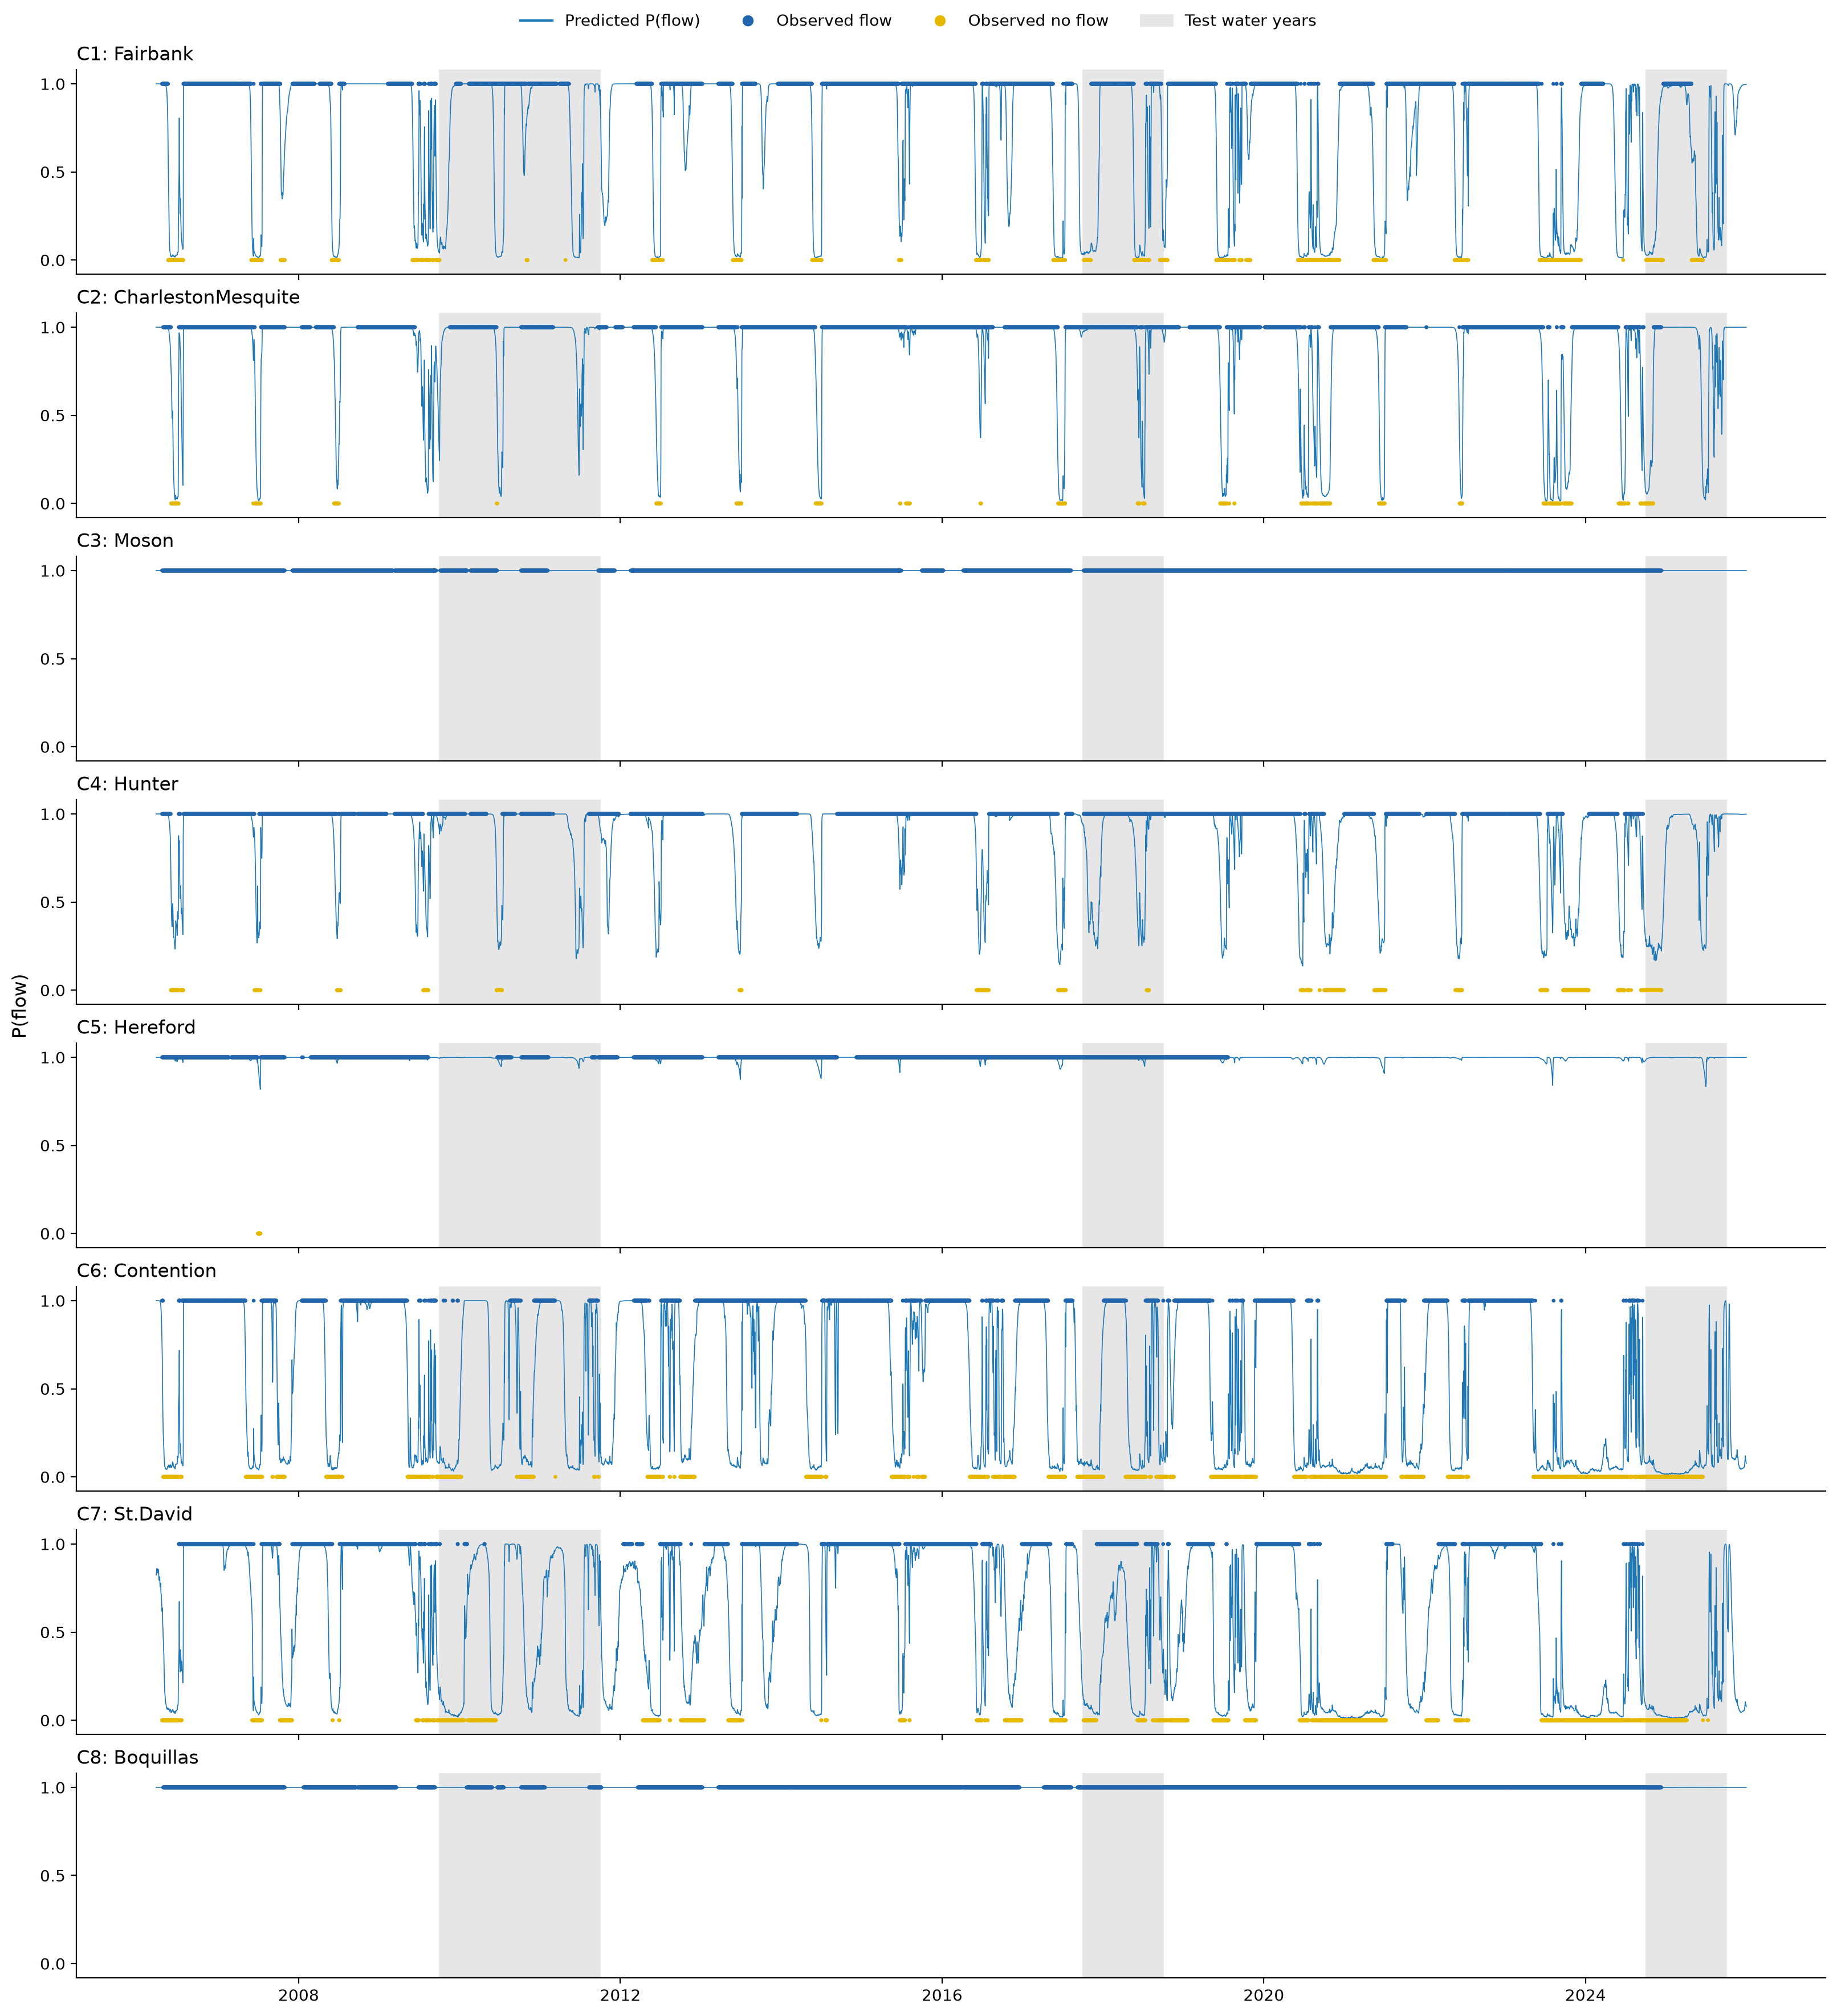

In [10]:
sites = sorted(cameras, key = cameras.get)
test = meta[te].copy()
test["correct"] = test["pred"] == test["fp"].astype(int)

fig, axes = plt.subplots(len(sites), 1, figsize = (18, 2.2 * len(sites)), sharex = True)
for ax, site in zip(axes, sites):
    sdata = out[out["site"] == site].sort_values("date")
    obs = sdata[sdata["source"] == "observed"]
    pred = sdata[(sdata["source"] == "predicted") & sdata["fp_final"].notna()]

    ax.vlines(obs.loc[obs["fp"] == 1, "date"], 0, 1, colors = "#2166ac", linewidth = 0.7, alpha = 0.9)
    ax.vlines(obs.loc[obs["fp"] == 0, "date"], 0, -1, colors = "#e6b800", linewidth = 0.5, alpha = 0.9)
    ax.vlines(pred.loc[pred["fp_final"] == 1, "date"], 0, 1, colors = "#92c5de", linewidth = 0.55, alpha = 0.9)
    ax.vlines(pred.loc[pred["fp_final"] == 0, "date"], 0, -1, colors = "#fff3a8", linewidth = 0.4, alpha = 0.9)

    stest = test[test["site"] == site]
    ax.scatter(stest.loc[stest["correct"], "date"], np.zeros(stest["correct"].sum()), color = "#1a9850", s = 22, zorder = 5, marker = "o")
    ax.scatter(stest.loc[~stest["correct"], "date"], np.zeros((~stest["correct"]).sum()), color = "#d7191c", s = 34, zorder = 6,
               marker = "x", linewidths = 1.2)

    ax.axhline(0, color = "black", linewidth = 0.5, linestyle = "--")
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(["0", "", "1"])
    ax.set_ylabel("FP", fontsize = 16, labelpad = 6)
    ax.set_title(re.sub(r"(?<=[a-z\.])(?=[A-Z])", " ", site), fontsize = 20, fontweight = "normal", loc = "left")
    ax.set_xlim(sdata["date"].min(), sdata["date"].max())
    ax.tick_params(axis = "x", labelsize = 16)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(1, -0.12, "*GF", transform = ax.transAxes, ha = "right", va = "top")

legend_handles = [
    mpatches.Patch(color = "#2166ac", label = "Wet"),
    mpatches.Patch(color = "#e6b800", label = "Dry"),
    mpatches.Patch(color = "#92c5de", label = "Predicted Wet"),
    mpatches.Patch(color = "#fff3a8", label = "Predicted Dry"),
    plt.scatter([], [], color = "#1a9850", s = 32, marker = "o", label = "Correct Test"),
    plt.scatter([], [], color = "#d7191c", s = 45, marker = "x", linewidths = 1.4, label = "Incorrect Test"),
]
fig.legend(handles = legend_handles, loc = "upper center", ncol = 6, fontsize = 20, bbox_to_anchor = (0.5, 0.96), frameon = False,
           borderpad = 0.08, borderaxespad = 0.02, handletextpad = 0.25, columnspacing = 0.45, handlelength = 1.1)

plt.suptitle("Flow Persistence BiLSTM Predictions", fontsize = 24, y = 0.992)
plt.tight_layout(rect = [0, 0.03, 1, 0.98])

# plt.savefig("../Figures/sprnca_bilstm.png", format = "png", dpi = 300, bbox_inches = "tight")